<a href="https://colab.research.google.com/github/prasanna-venkatesh-m/Analytics-Forecast/blob/main/SumofTotalPAR_Daily_Forecasting_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from xgboost import XGBRegressor, callback
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [104]:
df = pd.read_csv('/content/lag_data.csv')

columns_to_take = [
    'Date',
    'SumofTotalPAR'
]

data_df = df[columns_to_take].copy()

In [105]:
data_df['Date'] = pd.to_datetime(data_df['Date'], dayfirst=True)

grouped_df = data_df.groupby('Date').sum().reset_index()
grouped_df = grouped_df.sort_values('Date')

In [106]:
upper = grouped_df['SumofTotalPAR'].quantile(0.99)
grouped_df['SumofTotalPAR'] = np.clip(
    grouped_df['SumofTotalPAR'],
    None,
    upper
)

In [107]:
grouped_df['lag_1'] = grouped_df['SumofTotalPAR'].shift(1)
grouped_df['lag_2'] = grouped_df['SumofTotalPAR'].shift(2)
grouped_df['lag_3'] = grouped_df['SumofTotalPAR'].shift(3)
grouped_df['lag_7'] = grouped_df['SumofTotalPAR'].shift(7)
grouped_df['lag_14'] = grouped_df['SumofTotalPAR'].shift(14)
grouped_df['lag_30'] = grouped_df['SumofTotalPAR'].shift(30)

grouped_df['ema_7'] = grouped_df['SumofTotalPAR'].shift(1).ewm(span=7).mean()
grouped_df['ema_14'] = grouped_df['SumofTotalPAR'].shift(1).ewm(span=14).mean()
grouped_df['ema_30'] = grouped_df['SumofTotalPAR'].shift(1).ewm(span=30).mean()

grouped_df['diff_1'] = grouped_df['SumofTotalPAR'].diff(1)
grouped_df['diff_7'] = grouped_df['SumofTotalPAR'].diff(7)
grouped_df['pct_change_1'] = grouped_df['SumofTotalPAR'].pct_change(1)

grouped_df['day'] = grouped_df['Date'].dt.day
grouped_df['month'] = grouped_df['Date'].dt.month
grouped_df['dayofweek'] = grouped_df['Date'].dt.dayofweek
grouped_df['weekofyear'] = grouped_df['Date'].dt.isocalendar().week.astype(int)

grouped_df['sin_week'] = np.sin(2 * np.pi * grouped_df['dayofweek'] / 7)
grouped_df['cos_week'] = np.cos(2 * np.pi * grouped_df['dayofweek'] / 7)

In [108]:
grouped_df = grouped_df.dropna().reset_index(drop=True)
grouped_df['target'] = grouped_df['SumofTotalPAR']

In [109]:
features = [
    'lag_1','lag_2','lag_3','lag_7','lag_14','lag_30',
    'ema_7','ema_14','ema_30',
    'diff_1','diff_7','pct_change_1',
    'day','month','weekofyear',
    'sin_week','cos_week'
]

In [110]:
train_df = grouped_df[grouped_df['Date'] < '2026-04-01']
test_df = grouped_df[grouped_df['Date'] >= '2026-04-01']

X_train = train_df[features]
y_train = train_df['target']

X_test = test_df[features]
y_test = test_df['target']

In [111]:
model = XGBRegressor(
    n_estimators=5000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

In [112]:
model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=True
)

[0]	validation_0-rmse:696714279.84599
[1]	validation_0-rmse:674149805.14835
[2]	validation_0-rmse:653406610.87337
[3]	validation_0-rmse:633265331.70151
[4]	validation_0-rmse:613233824.64133
[5]	validation_0-rmse:594520718.77792
[6]	validation_0-rmse:576556585.81973
[7]	validation_0-rmse:557732225.34345
[8]	validation_0-rmse:539594954.96070
[9]	validation_0-rmse:522285620.73550
[10]	validation_0-rmse:505542143.25856
[11]	validation_0-rmse:489966463.13272
[12]	validation_0-rmse:474351423.93469
[13]	validation_0-rmse:459842413.73925
[14]	validation_0-rmse:445689699.77083
[15]	validation_0-rmse:431715241.41834
[16]	validation_0-rmse:418244932.75985
[17]	validation_0-rmse:406101577.86430
[18]	validation_0-rmse:393604993.39434
[19]	validation_0-rmse:383091113.17689
[20]	validation_0-rmse:371760499.11021
[21]	validation_0-rmse:361685296.41822
[22]	validation_0-rmse:352422112.99377
[23]	validation_0-rmse:342548160.59636
[24]	validation_0-rmse:332866401.69790
[25]	validation_0-rmse:323552790.12

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=5000,
             n_jobs=None, num_parallel_tree=None, ...)

In [113]:
preds = model.predict(X_test)

In [114]:
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
mape = np.mean(np.abs((y_test - preds) / y_test)) * 100

print("\n====================")
print("MODEL PERFORMANCE")
print("====================")
print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAPE: {mape:.2f}%")


MODEL PERFORMANCE
MAE : 16,137,866.34
RMSE: 29,118,947.04
MAPE: 0.95%


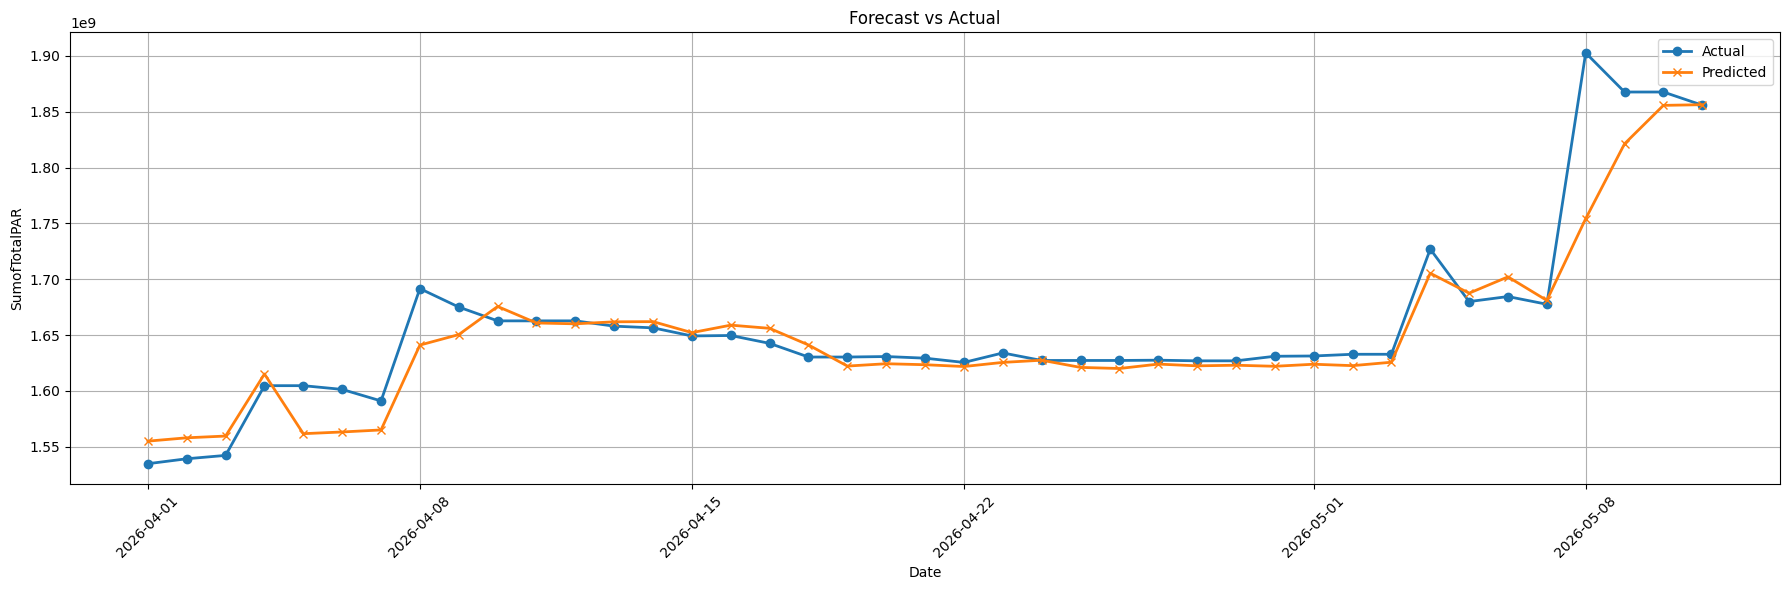

In [115]:
plt.figure(figsize=(18,6))

plt.plot(test_df['Date'], y_test, label='Actual', linewidth=2, marker='o')
plt.plot(test_df['Date'], preds, label='Predicted', linewidth=2, marker='x')

plt.title("Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("SumofTotalPAR")

plt.legend()
plt.grid()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


Feature Importance:
         Feature  Importance
4         lag_14    0.312263
3          lag_7    0.230198
6          ema_7    0.227215
0          lag_1    0.091345
7         ema_14    0.060781
2          lag_3    0.057120
1          lag_2    0.019368
5         lag_30    0.000982
14    weekofyear    0.000388
10        diff_7    0.000209
8         ema_30    0.000073
9         diff_1    0.000026
11  pct_change_1    0.000018
13         month    0.000008
12           day    0.000002
15      sin_week    0.000002
16      cos_week    0.000002


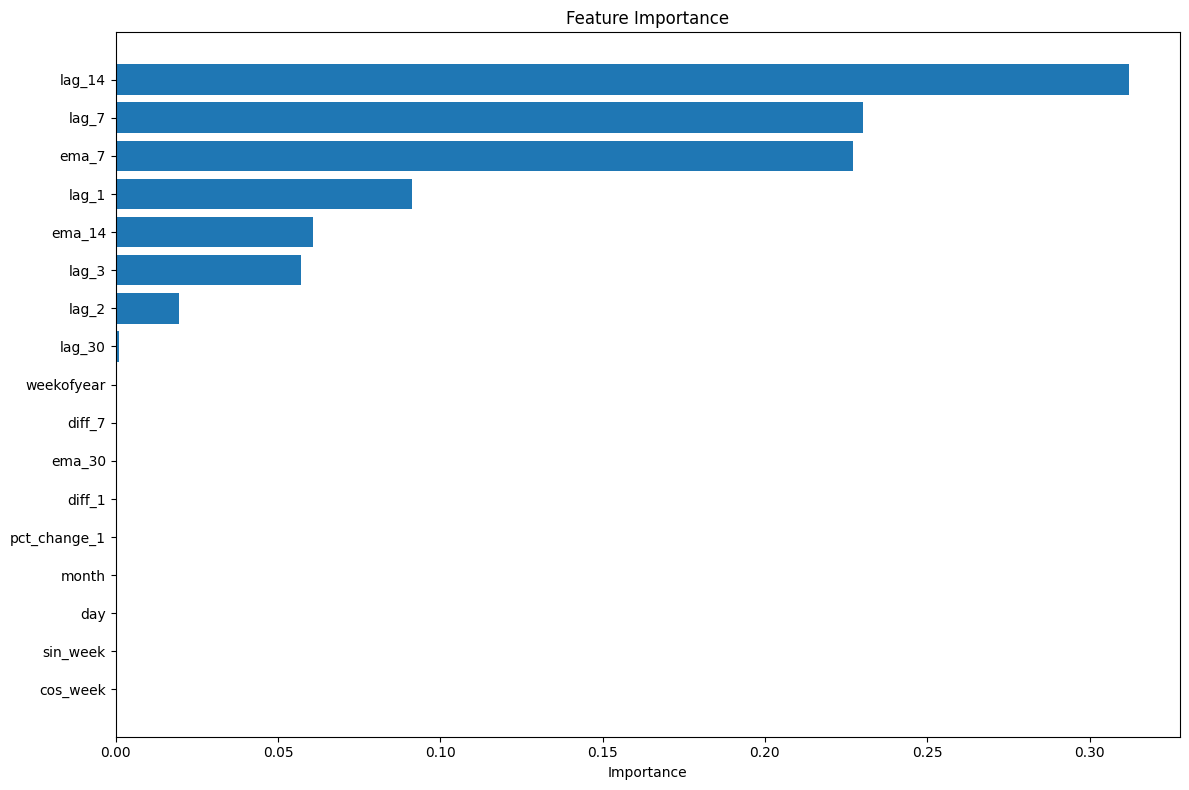

In [116]:
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(importance_df)

plt.figure(figsize=(12, 8))

plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.gca().invert_yaxis()

plt.title('Feature Importance')

plt.xlabel('Importance')

plt.tight_layout()

plt.show()